In [3]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

data_dir = Path("../../datasets").resolve()
data_dir.mkdir(parents=True, exist_ok=True)

print("Dataset directory found")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root=str(data_dir),
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root=str(data_dir),
    train=False,
    download=True,
    transform=transform,
)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

classes = tuple(str(i) for i in range(10))
print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Input tensor shape: {train_dataset[0][0].shape}")


Dataset directory found
Using device: cuda
Train samples: 60000
Test samples: 10000
Input tensor shape: torch.Size([1, 28, 28])


### Note on installation and package version

> Suggested stable conda environment for this notebook
>
> Why these packages: this imports cell needs `numpy`, `matplotlib`, `torch`, `torchvision`, and Jupyter kernel support. The most common crash source here is mixing a CUDA-enabled `torch` with a mismatched `torchvision`, or using very new `numpy` builds with older compiled packages. A safe combination is:
>
> - `python=3.10`
> - `numpy=1.26.4`
> - `matplotlib=3.8.4`
> - `pytorch=2.5.1`
> - `torchvision=0.20.1`
> - `pytorch-cuda=12.1`
> - `ipykernel=6.29.5`
> - `jupyterlab=4.2.5`
>
> Recommended commands:
>
> ```bash
> conda create -n mnist_cuda python=3.10 numpy=1.26.4 matplotlib=3.8.4 ipykernel=6.29.5 jupyterlab=4.2.5 -y
> conda activate mnist_cuda
> conda install pytorch=2.5.1 torchvision=0.20.1 pytorch-cuda=12.1 -c pytorch -c nvidia -y
> python -m ipykernel install --user --name mnist_cuda --display-name "Python (mnist_cuda)"
> ```
>
> Notes:
>
> - Install `torch` and `torchvision` together in one conda command so they stay ABI-compatible.
> - Keep `numpy` pinned to `1.26.4` for maximum compatibility with compiled scientific packages.
> - After creating the environment, restart Jupyter fully and switch the notebook kernel to `Python (mnist_cuda)` to avoid dead-kernel issues caused by reusing an old kernel process.
> - If you do not want GPU, replace the PyTorch install line with `conda install pytorch=2.5.1 torchvision=0.20.1 cpuonly -c pytorch -y`.


## MNIST dataset notes

- **Task**: classify handwritten digits from 0 to 9.
- **Input type**: grayscale image, not RGB. Each image has a single channel.
- **Original image size**: `28 x 28` pixels.
- **Tensor shape after `ToTensor()`**: `(1, 28, 28)`.
- **Pixel range after `ToTensor()`**: floating-point values in `[0, 1]`.
- **Targets**: integer class labels from `0` to `9`.
- **Dataset size**: 60,000 training images and 10,000 test images.
- **Why this matters here**: for standard MNIST classifiers we usually keep the full pipeline simple: tensor conversion, minibatch loading, cross-entropy loss, optimizer, train/test split, and accuracy tracking. The same training loop can later be reused for filtered or enlarged MNIST-like inputs, as long as the model input shape is updated consistently.


## Small classifier

In [4]:
def count_trainable_parameters(model):
    return sum(param.numel() for param in model.parameters() if param.requires_grad)


def print_model_summary(model, input_shape=(1, 1, 28, 28)):
    print(model)
    print(f"Trainable parameters: {count_trainable_parameters(model):,}")
    with torch.no_grad():
        sample = torch.zeros(input_shape, device=device)
        output = model(sample)
    print(f"Output shape for input {input_shape}: {tuple(output.shape)}")


def evaluate_model(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            logits = model(inputs)
            loss = criterion(logits, targets)

            total_loss += loss.item() * inputs.size(0)
            total_correct += (logits.argmax(dim=1) == targets).sum().item()
            total_examples += inputs.size(0)

    return total_loss / total_examples, total_correct / total_examples


def train_model(model, train_loader, test_loader, epochs=8, lr=1e-3, weight_decay=0.0):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        running_correct = 0
        seen_examples = 0
        start_time = time.time()

        for inputs, targets in train_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()
            logits = model(inputs)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_correct += (logits.argmax(dim=1) == targets).sum().item()
            seen_examples += inputs.size(0)

        train_loss = running_loss / seen_examples
        train_acc = running_correct / seen_examples
        test_loss, test_acc = evaluate_model(model, test_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        elapsed = time.time() - start_time
        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss {train_loss:.4f} | train acc {train_acc:.4%} | "
            f"test loss {test_loss:.4f} | test acc {test_acc:.4%} | "
            f"time {elapsed:.1f}s"
        )

    return history


class SmallMNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [5]:
small_model = SmallMNISTCNN().to(device)
print_model_summary(small_model)

print("\nThis is the standard MNIST training procedure we will also reuse later:")
print("1. Build DataLoaders for train/test data.")
print("2. Define model, loss, optimizer.")
print("3. Train over minibatches with gradient updates.")
print("4. Evaluate on held-out test data after each epoch.")
print("5. Plot loss/accuracy history.")
print("For filtered or enlarged images, the same loop still applies; only the transform pipeline and possibly the model input block need to change.")

small_history = train_model(
    small_model,
    train_loader,
    test_loader,
    epochs=8,
    lr=1e-3,
)


SmallMNISTCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
Trainable parameters: 206,922
Output shape for input (1, 1, 28, 28): (1, 10)

This is the standard MNIST training procedure we will also reuse later:
1. Build DataLoaders for train/test data.
2. Define model, loss, optimizer.
3. Train over minibatches with gradient updates.
4. Evaluate on held-out test data after each epoch.
5. Plot loss/accuracy hi

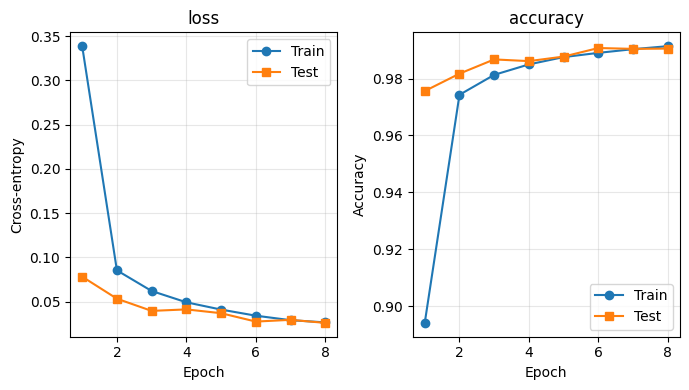

Final train accuracy: 99.1350%
Final test accuracy: 99.0500%


In [6]:
history = small_history
epochs = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(7, 4))

axes[0].plot(epochs, history["train_loss"], marker="o", label="Train")
axes[0].plot(epochs, history["test_loss"], marker="s", label="Test")
axes[0].set_title("loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(epochs, history["train_acc"], marker="o", label="Train")
axes[1].plot(epochs, history["test_acc"], marker="s", label="Test")
axes[1].set_title("accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Final train accuracy: {small_history['train_acc'][-1]:.4%}")
print(f"Final test accuracy: {small_history['test_acc'][-1]:.4%}")


## Deep precise classifier

In [7]:
class DeepMNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


In [8]:
deep_model = DeepMNISTCNN().to(device)
print_model_summary(deep_model)

deep_history = train_model(
    deep_model,
    train_loader,
    test_loader,
    epochs=10,
    lr=8e-4,
    weight_decay=1e-4,
)

DeepMNISTCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.25, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Dropout(p=0.25, in

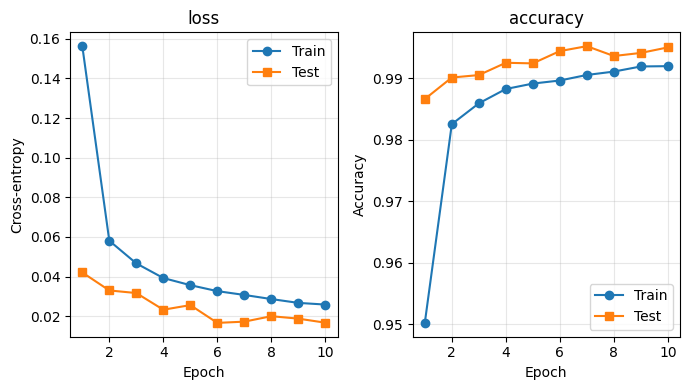

Final train accuracy: 99.1950%
Final test accuracy: 99.5000%
This deeper classifier is a typical strong MNIST baseline and should usually reach roughly 99% test accuracy when trained cleanly on standard MNIST.
So 92-95% is comfortably achievable; if you later apply harder filtering or image enlargement, this model gives you headroom for accuracy loss.


In [9]:
history2 = deep_history
title="Deep MNIST CNN"
epochs = range(1, len(history2["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(7, 4))

axes[0].plot(epochs, history2["train_loss"], marker="o", label="Train")
axes[0].plot(epochs, history2["test_loss"], marker="s", label="Test")
axes[0].set_title("loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(epochs, history2["train_acc"], marker="o", label="Train")
axes[1].plot(epochs, history2["test_acc"], marker="s", label="Test")
axes[1].set_title("accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Final train accuracy: {deep_history['train_acc'][-1]:.4%}")
print(f"Final test accuracy: {deep_history['test_acc'][-1]:.4%}")
print("This deeper classifier is a typical strong MNIST baseline and should usually reach roughly 99% test accuracy when trained cleanly on standard MNIST.")
print("So 92-95% is comfortably achievable; if you later apply harder filtering or image enlargement, this model gives you headroom for accuracy loss.")


## Benchmark on double image (image + filtered)

In [7]:
class DoubleImageDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset):
        self.base_dataset = base_dataset

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, target = self.base_dataset[idx]
        squared_image = image.square()
        double_image = torch.cat([image, squared_image], dim=2)
        return double_image, target


double_train_dataset = DoubleImageDataset(train_dataset)
double_test_dataset = DoubleImageDataset(test_dataset)

double_train_loader = DataLoader(double_train_dataset, batch_size=batch_size, shuffle=True)
double_test_loader = DataLoader(double_test_dataset, batch_size=batch_size, shuffle=False)


class SmallDoubleImageCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((7, 7)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


double_small_model = SmallDoubleImageCNN().to(device)
print_model_summary(double_small_model, input_shape=(1, 1, 28, 56))

double_small_history = train_model(
    double_small_model,
    double_train_loader,
    double_test_loader,
    epochs=8,
    lr=1e-3,
)


SmallDoubleImageCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): AdaptiveAvgPool2d(output_size=(7, 7))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
Trainable parameters: 206,922
Output shape for input (1, 1, 28, 56): (1, 10)
Epoch 01/8 | train loss 0.3446 | train acc 89.5533% | test loss 0.0767 | test acc 97.4000% | time 10.8s
Epoch 02/8 | train loss 0.0902 | train acc 97.2700% | test loss 0.0503 | test acc 98.4600% | time 11.4s
Epoch 03/8 | 

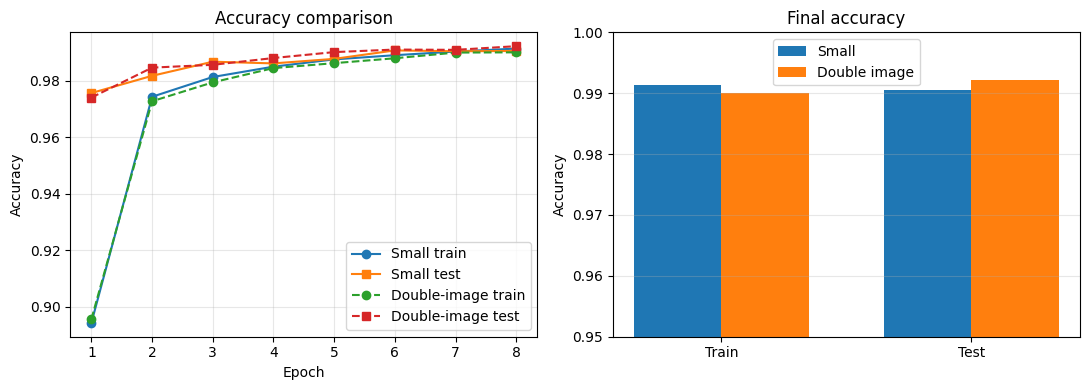

Final performance summary
Small classifier      | train: 99.1350% | test: 99.0500%
Double-image classifier | train: 99.0017% | test: 99.2200%


In [10]:
required_histories = {
    "small_history": globals().get("small_history"),
    "double_small_history": globals().get("double_small_history"),
}
missing_histories = [name for name, value in required_histories.items() if value is None]
if missing_histories:
    raise RuntimeError(
        "Run the original small-classifier cell and the double-image training cell first. "
        f"Missing: {', '.join(missing_histories)}"
    )

epochs_small = range(1, len(small_history["train_acc"]) + 1)
epochs_double = range(1, len(double_small_history["train_acc"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(epochs_small, small_history["train_acc"], marker="o", label="Small train")
axes[0].plot(epochs_small, small_history["test_acc"], marker="s", label="Small test")
axes[0].plot(epochs_double, double_small_history["train_acc"], marker="o", linestyle="--", label="Double-image train")
axes[0].plot(epochs_double, double_small_history["test_acc"], marker="s", linestyle="--", label="Double-image test")
axes[0].set_title("Accuracy comparison")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

labels = ["Train", "Test"]
small_final = [small_history["train_acc"][-1], small_history["test_acc"][-1]]
double_final = [double_small_history["train_acc"][-1], double_small_history["test_acc"][-1]]
x = np.arange(len(labels))
width = 0.35

axes[1].bar(x - width / 2, small_final, width, label="Small")
axes[1].bar(x + width / 2, double_final, width, label="Double image")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylim(0.95, 1.0)
axes[1].set_title("Final accuracy")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True, axis="y", alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig("accuracy_comparison_mnist_digits_small_classifiers.pdf", dpi=300)
plt.show()

print("Final performance summary")
print(f"Small classifier      | train: {small_history['train_acc'][-1]:.4%} | test: {small_history['test_acc'][-1]:.4%}")
print(f"Double-image classifier | train: {double_small_history['train_acc'][-1]:.4%} | test: {double_small_history['test_acc'][-1]:.4%}")
